In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


In [77]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
#%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"
%cd "/content/drive/MyDrive/Final Assignment"

/content/drive/MyDrive/Final Assignment


In [79]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/Final Assignment/telecom/Record.csv


In [80]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [81]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


In [82]:
df.columns

Index(['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
       'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean',
       'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean',
       'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean',
       'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean',
       'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean',
       'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean',
       'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean',
       'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean',
       'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean',
       'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'churn', 'months',
       'Customer_ID', 'uniqsubs', 'actvsubs', 'new_cell', 'crclscod',
       'asl_flag', 'totcalls', 'totmou', 'to

In [83]:
df.dtypes

,0
rev_Mean,float64
mou_Mean,float64
totmrc_Mean,float64
da_Mean,float64
ovrmou_Mean,float64
ovrrev_Mean,float64
vceovr_Mean,float64
datovr_Mean,float64
roam_Mean,float64
change_mou,float64


In [84]:
df.shape
# number of data points
print(f" There are {df.shape[0]} rows and {df.shape[1]} columns")

 There are 100000 rows and 100 columns


In [85]:
# Count missing values
df.isna().sum()

,0
rev_Mean,357
mou_Mean,357
totmrc_Mean,357
da_Mean,357
ovrmou_Mean,357
ovrrev_Mean,357
vceovr_Mean,357
datovr_Mean,357
roam_Mean,357
change_mou,891


In [86]:
percent_missing = df.isnull().sum() * 100 / len(df)
print(percent_missing.sort_values(ascending=False).head(20))

numbcars            49.366
dwllsize            38.308
HHstatin            37.923
ownrent             33.706
dwlltype            31.909
lor                 30.190
income              25.436
adults              23.019
infobase            22.079
hnd_webcap          10.189
prizm_social_one     7.388
avg6mou              2.839
avg6qty              2.839
avg6rev              2.839
truck                1.732
rv                   1.732
kid11_15             1.732
kid16_17             1.732
marital              1.732
forgntvl             1.732
dtype: float64


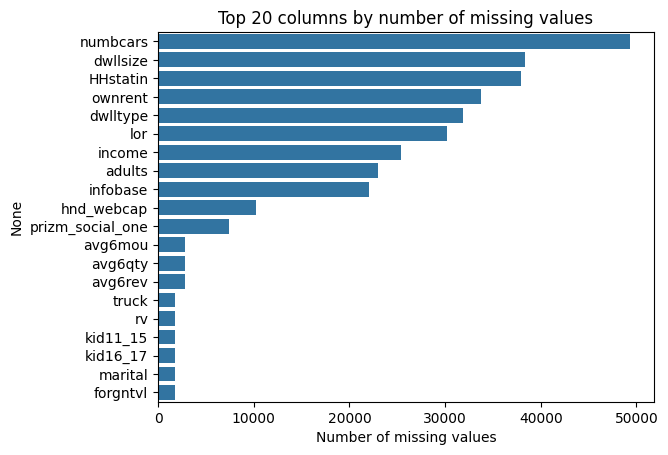

In [87]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

In [88]:
duplicated_entries = df[df.duplicated()]
duplicated_entries.shape

(0, 100)

array([[<Axes: title={'center': 'rev_Mean'}>,
        <Axes: title={'center': 'mou_Mean'}>,
        <Axes: title={'center': 'totmrc_Mean'}>,
        <Axes: title={'center': 'da_Mean'}>,
        <Axes: title={'center': 'ovrmou_Mean'}>,
        <Axes: title={'center': 'ovrrev_Mean'}>,
        <Axes: title={'center': 'vceovr_Mean'}>,
        <Axes: title={'center': 'datovr_Mean'}>,
        <Axes: title={'center': 'roam_Mean'}>],
       [<Axes: title={'center': 'change_mou'}>,
        <Axes: title={'center': 'change_rev'}>,
        <Axes: title={'center': 'drop_vce_Mean'}>,
        <Axes: title={'center': 'drop_dat_Mean'}>,
        <Axes: title={'center': 'blck_vce_Mean'}>,
        <Axes: title={'center': 'blck_dat_Mean'}>,
        <Axes: title={'center': 'unan_vce_Mean'}>,
        <Axes: title={'center': 'unan_dat_Mean'}>,
        <Axes: title={'center': 'plcd_vce_Mean'}>],
       [<Axes: title={'center': 'plcd_dat_Mean'}>,
        <Axes: title={'center': 'recv_vce_Mean'}>,
        <Axes:

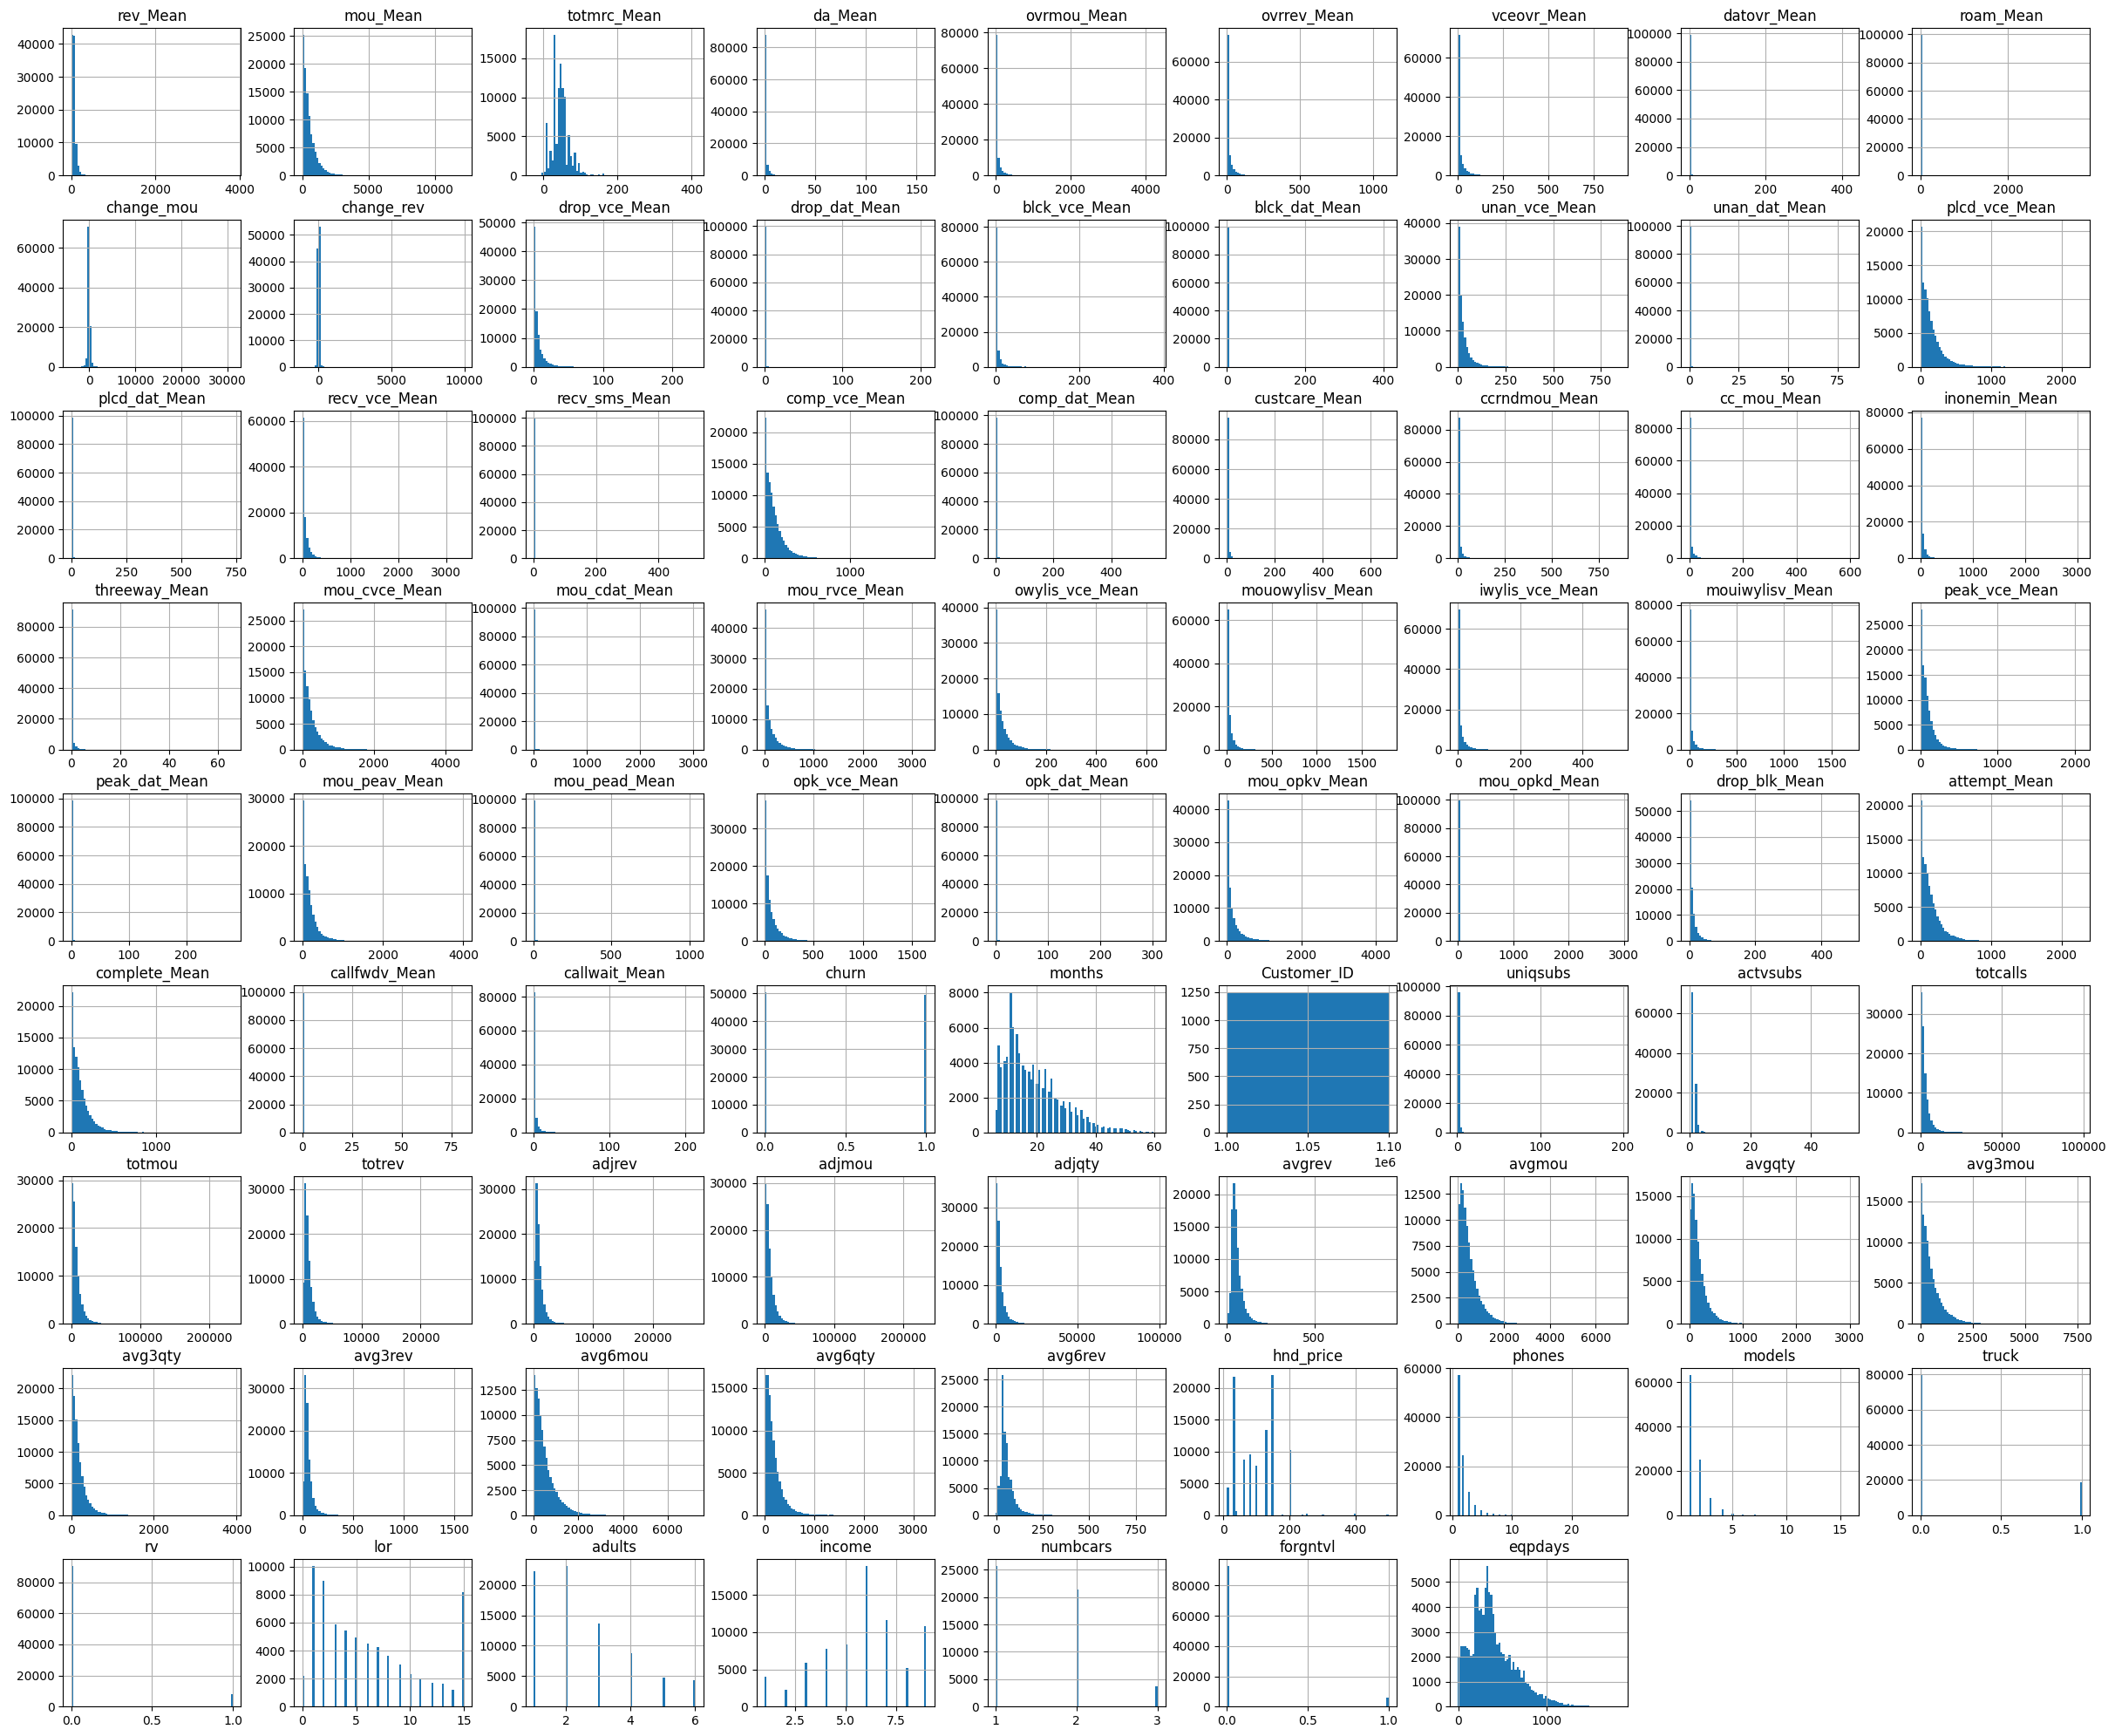

In [89]:
df.hist(bins=80, figsize=(30,25))

In [90]:
df = df.drop_duplicates()

In [91]:
df.columns

Index(['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
       'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean',
       'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean',
       'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean',
       'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean',
       'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean',
       'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean',
       'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean',
       'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean',
       'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean',
       'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'churn', 'months',
       'Customer_ID', 'uniqsubs', 'actvsubs', 'new_cell', 'crclscod',
       'asl_flag', 'totcalls', 'totmou', 'to

In [92]:
df = df.loc[:, df.isna().mean() <= 0.30]

In [93]:
df = df.fillna(df.mean(numeric_only=True))

In [95]:
# Select only categorical/object columns
cat_columns = df.select_dtypes(include=['object', 'category']).columns

# Fill each column with its mode
for col in cat_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [96]:
percent_missing = df.isnull().sum() * 100 / len(df)
print(percent_missing.sort_values(ascending=False).head(20))

rev_Mean         0.0
mou_Mean         0.0
totmrc_Mean      0.0
da_Mean          0.0
ovrmou_Mean      0.0
ovrrev_Mean      0.0
vceovr_Mean      0.0
datovr_Mean      0.0
roam_Mean        0.0
change_mou       0.0
change_rev       0.0
drop_vce_Mean    0.0
drop_dat_Mean    0.0
blck_vce_Mean    0.0
blck_dat_Mean    0.0
unan_vce_Mean    0.0
unan_dat_Mean    0.0
plcd_vce_Mean    0.0
plcd_dat_Mean    0.0
recv_vce_Mean    0.0
dtype: float64


In [98]:
df.describe()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,hnd_price,phones,models,truck,rv,adults,income,forgntvl,eqpdays
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,58.719985,513.559937,46.179136,0.888828,41.072247,13.559560,13.295062,0.261318,1.286405,-13.933818,-1.021067,5.955085,0.040520,4.022917,0.025777,27.784905,0.029810,144.881677,0.870548,55.085152,0.047590,108.892535,0.774442,1.790838,4.666880,3.683328,29.766550,0.284720,227.763520,1.844036,111.654562,24.753320,28.467865,7.894360,18.193037,88.480285,0.358162,174.080788,0.707832,66.003498,0.416283,165.280703,1.135804,10.044298,145.752225,109.666977,0.011700,1.782928,0.495620,18.833990,1.050000e+06,1.548140,1.358960,2877.141930,7648.363833,1031.924988,960.111528,7546.314699,2836.366920,57.913832,483.726493,173.554507,519.641210,180.337320,59.193330,509.634576,178.365157,58.683618,101.875763,1.787118,1.545825,0.188820,0.082580,2.530326,5.783112,0.057974,391.932309
std,46.208972,524.229868,23.581283,2.173729,97.122320,30.446392,30.002391,3.120946,14.685090,274.854774,50.138337,8.954715,0.877136,10.672202,1.490255,38.358734,0.496970,158.267711,9.053901,86.841198,2.127422,118.580079,8.129844,5.315570,12.761953,10.539981,55.833753,1.092101,264.403894,23.733226,162.691285,34.414822,48.962903,16.145590,41.421462,103.066103,4.065630,207.673553,8.410151,91.456885,4.652627,237.332918,17.768683,15.418406,159.348094,119.594305,0.547470,5.353953,0.499983,9.655794,2.886766e+04,1.075255,0.655555,3790.863474,8666.558293,852.907511,840.170815,8594.889729,3756.513882,36.161292,438.485213,167.824576,533.634073,192.725835,46.695429,489.562483,180.112088,40.175838,60.746760,1.313971,0.898391,0.387964,0.272854,1.274685,1.884277,0.231663,256.480910
min,-6.167500,0.000000,-26.915000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000001e+06,1.000000,0.000000,0.000000,

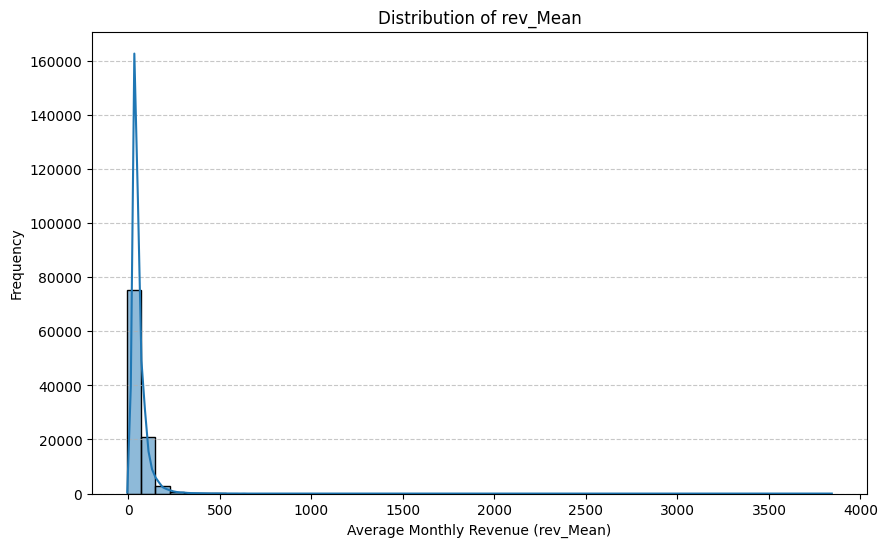

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['rev_Mean'], bins=50, kde=True)
plt.title('Distribution of rev_Mean')
plt.xlabel('Average Monthly Revenue (rev_Mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

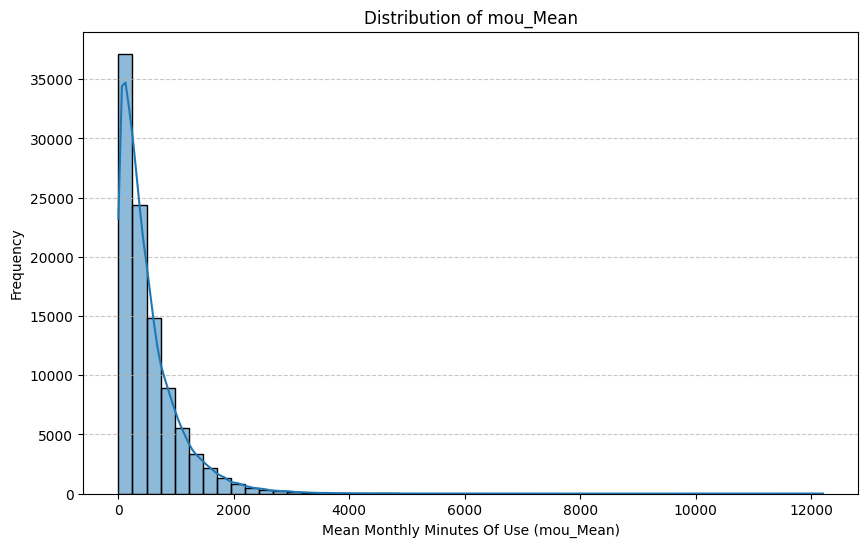

In [119]:
plt.figure(figsize=(10, 6))
sns.histplot(df['mou_Mean'], bins=50, kde=True)
plt.title('Distribution of mou_Mean')
plt.xlabel('Mean Monthly Minutes Of Use (mou_Mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

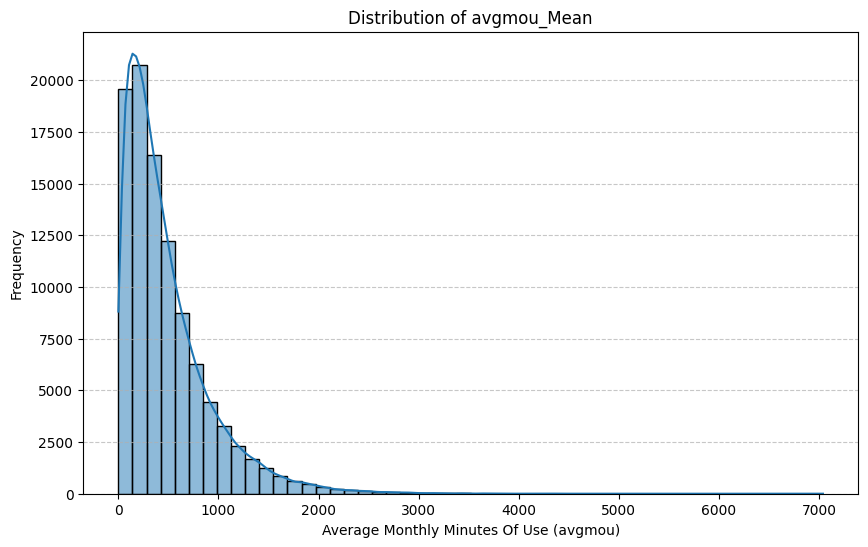

In [111]:
plt.figure(figsize=(10, 6))
sns.histplot(df['avgmou'], bins=50, kde=True)
plt.title('Distribution of avgmou_Mean')
plt.xlabel('Average Monthly Minutes Of Use (avgmou)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

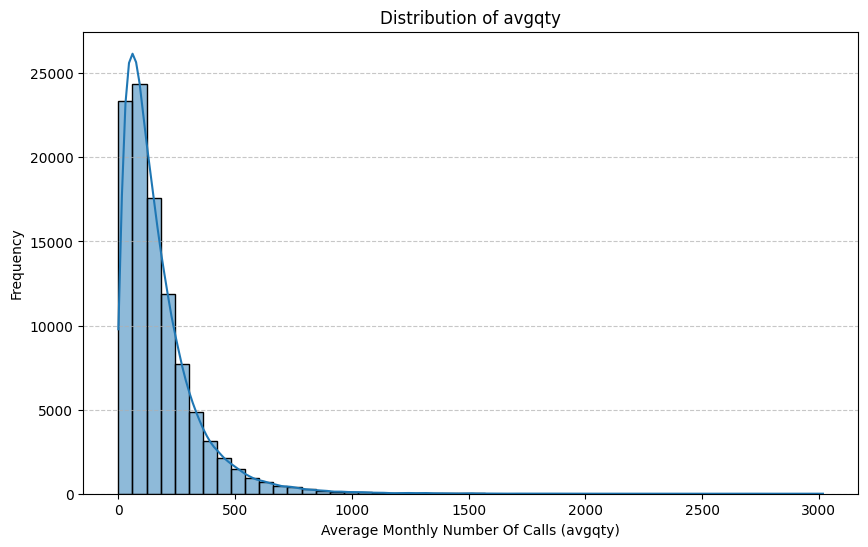

In [112]:
plt.figure(figsize=(10, 6))
sns.histplot(df['avgqty'], bins=50, kde=True)
plt.title('Distribution of avgqty')
plt.xlabel('Average Monthly Number Of Calls (avgqty)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

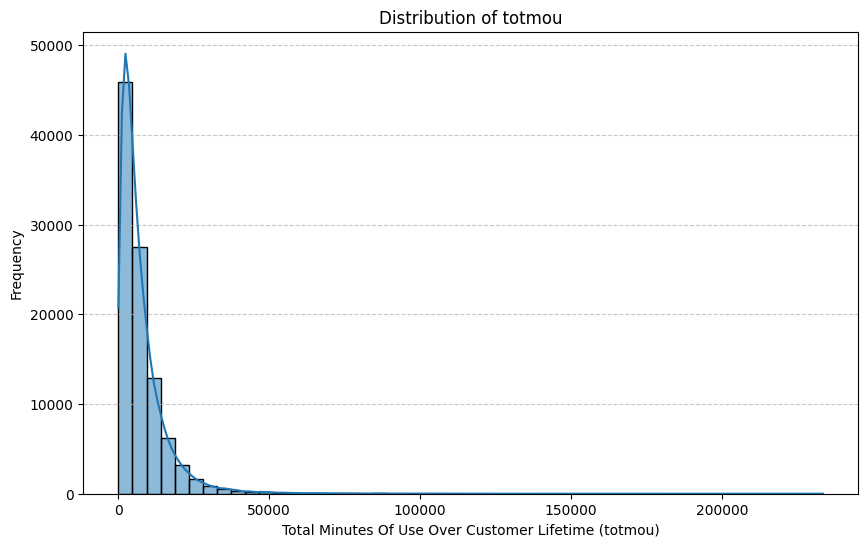

In [113]:
plt.figure(figsize=(10, 6))
sns.histplot(df['totmou'], bins=50, kde=True)
plt.title('Distribution of totmou')
plt.xlabel('Total Minutes Of Use Over Customer Lifetime (totmou)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

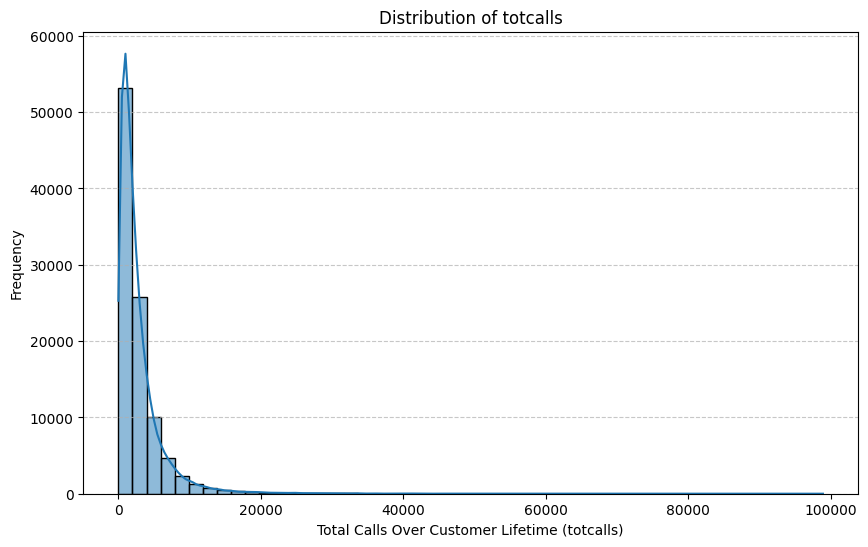

In [115]:
plt.figure(figsize=(10, 6))
sns.histplot(df['totcalls'], bins=50, kde=True)
plt.title('Distribution of totcalls')
plt.xlabel('Total Calls Over Customer Lifetime (totcalls)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

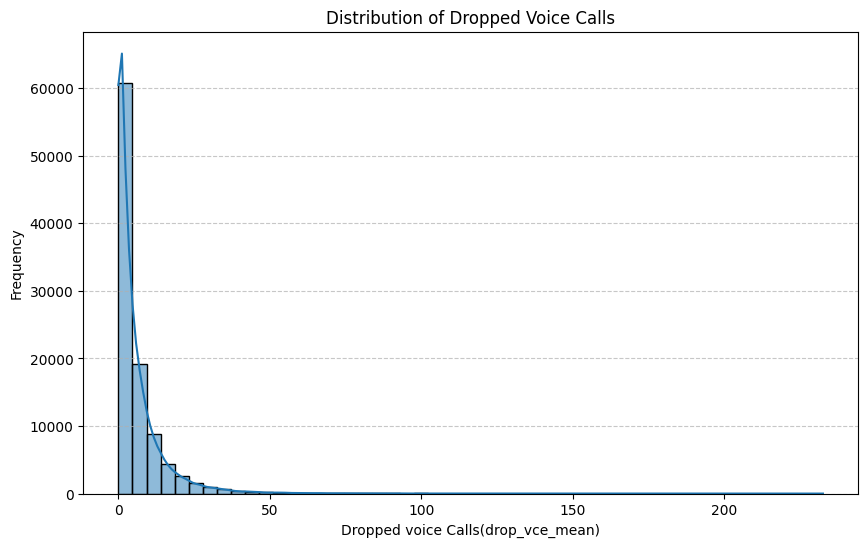

In [101]:
plt.figure(figsize=(10, 6))
sns.histplot(df['drop_vce_Mean'], bins=50, kde=True)
plt.title('Distribution of Dropped Voice Calls')
plt.xlabel('Dropped voice Calls(drop_vce_mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

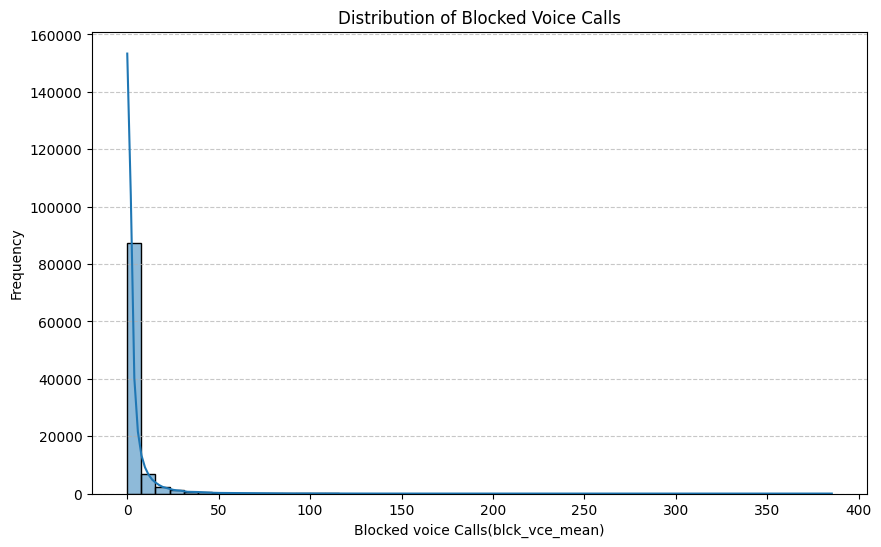

In [105]:
plt.figure(figsize=(10, 6))
sns.histplot(df['blck_vce_Mean'], bins=50, kde=True)
plt.title('Distribution of Blocked Voice Calls')
plt.xlabel('Blocked voice Calls(blck_vce_mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

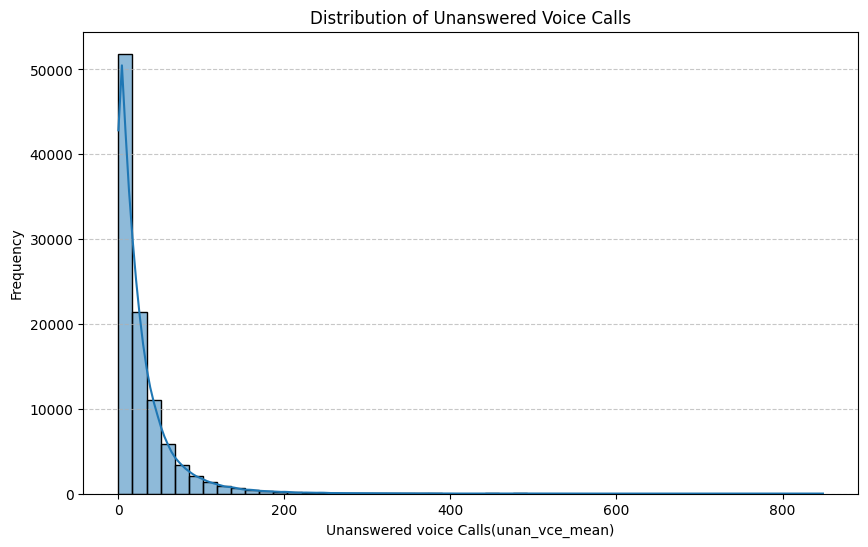

In [106]:
plt.figure(figsize=(10, 6))
sns.histplot(df['unan_vce_Mean'], bins=50, kde=True)
plt.title('Distribution of Unanswered Voice Calls')
plt.xlabel('Unanswered voice Calls(unan_vce_mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

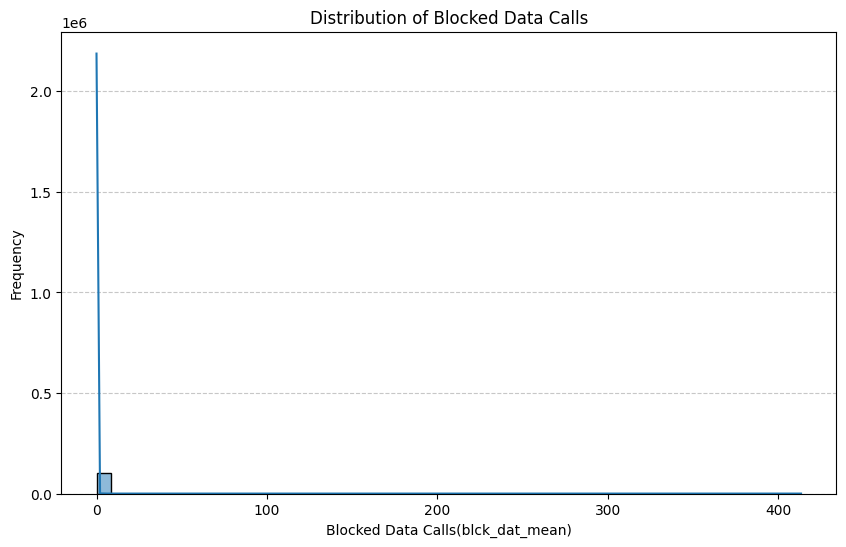

In [103]:
plt.figure(figsize=(10, 6))
sns.histplot(df['blck_dat_Mean'], bins=50, kde=True)
plt.title('Distribution of Blocked Data Calls')
plt.xlabel('Blocked Data Calls(blck_dat_mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

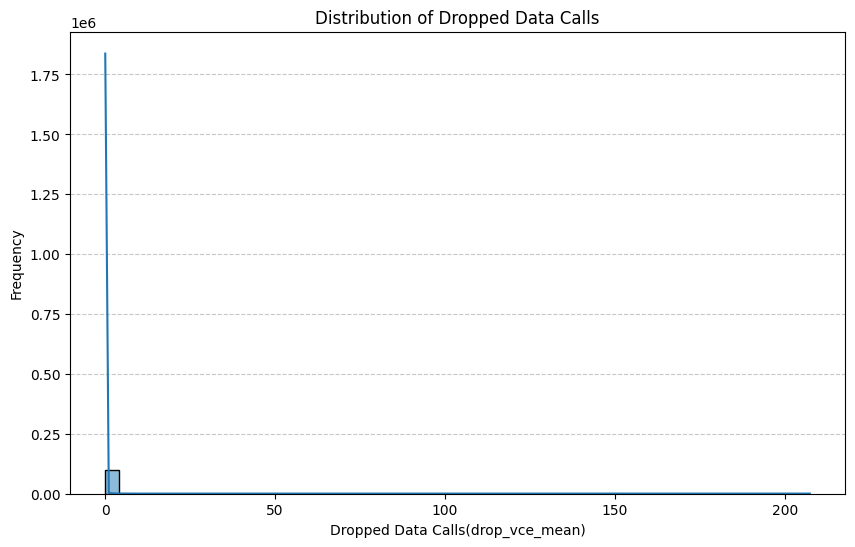

In [102]:
plt.figure(figsize=(10, 6))
sns.histplot(df['drop_dat_Mean'], bins=50, kde=True)
plt.title('Distribution of Dropped Data Calls')
plt.xlabel('Dropped Data Calls(drop_vce_mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

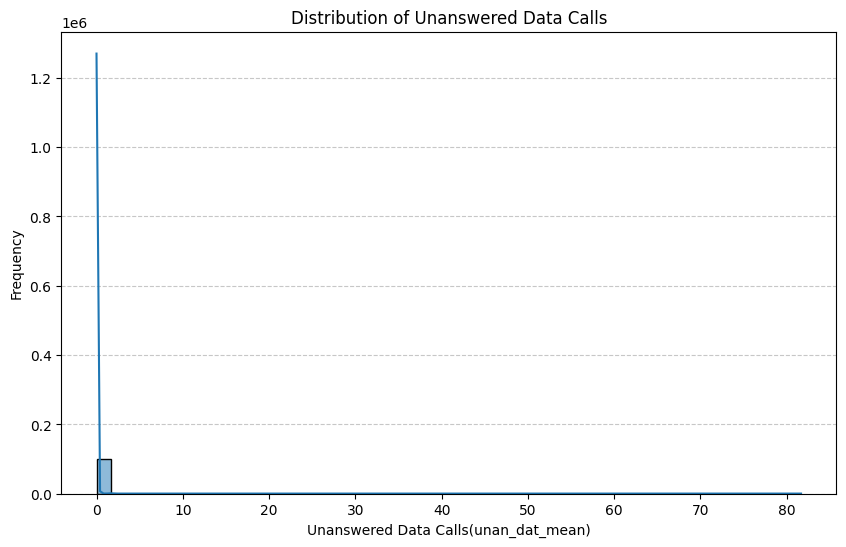

In [107]:
plt.figure(figsize=(10, 6))
sns.histplot(df['unan_dat_Mean'], bins=50, kde=True)
plt.title('Distribution of Unanswered Data Calls')
plt.xlabel('Unanswered Data Calls(unan_dat_mean)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Correlation between usage and failure metrics


In [121]:
usage_failure_corr = df[['rev_Mean','mou_Mean','avgmou','avgqty','totmou', 'totcalls', 'drop_vce_Mean', 'blck_vce_Mean', 'unan_vce_Mean', 'blck_dat_Mean', 'drop_dat_Mean', 'unan_dat_Mean']].corr()

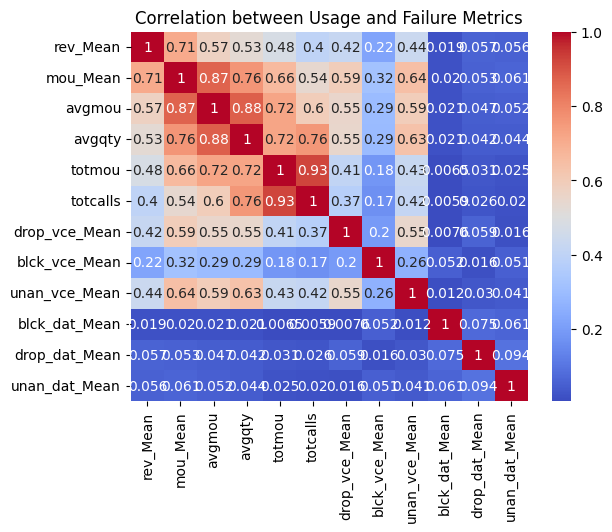

In [122]:
sns.heatmap(usage_failure_corr, annot=True, cmap='coolwarm')
plt.title('Correlation between Usage and Failure Metrics')
plt.show()

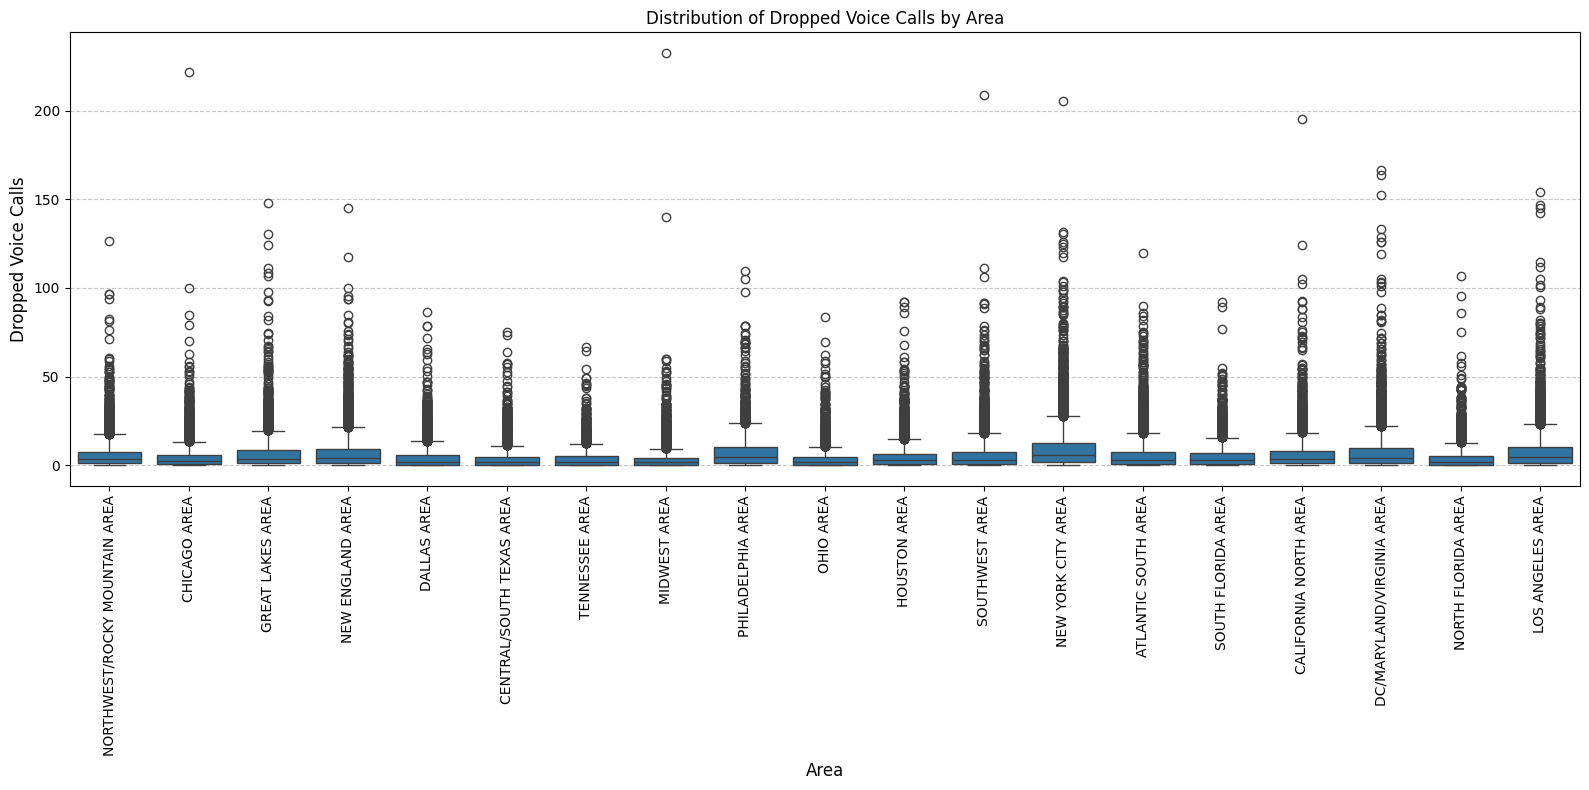

In [123]:
plt.figure(figsize=(16, 8)) # Increased figure size
sns.boxplot(x='area',y='drop_vce_Mean',data=df)
plt.title('Distribution of Dropped Voice Calls by Area')
plt.xlabel('Area', fontsize=12)
plt.ylabel('Dropped Voice Calls', fontsize=12) # Increased y-axis label font size
plt.xticks(rotation=90, fontsize=10) # Rotate x-axis labels for better readability and increased font size
plt.yticks(fontsize=10) # Increased y-axis tick label font size
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added horizontal grid lines
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

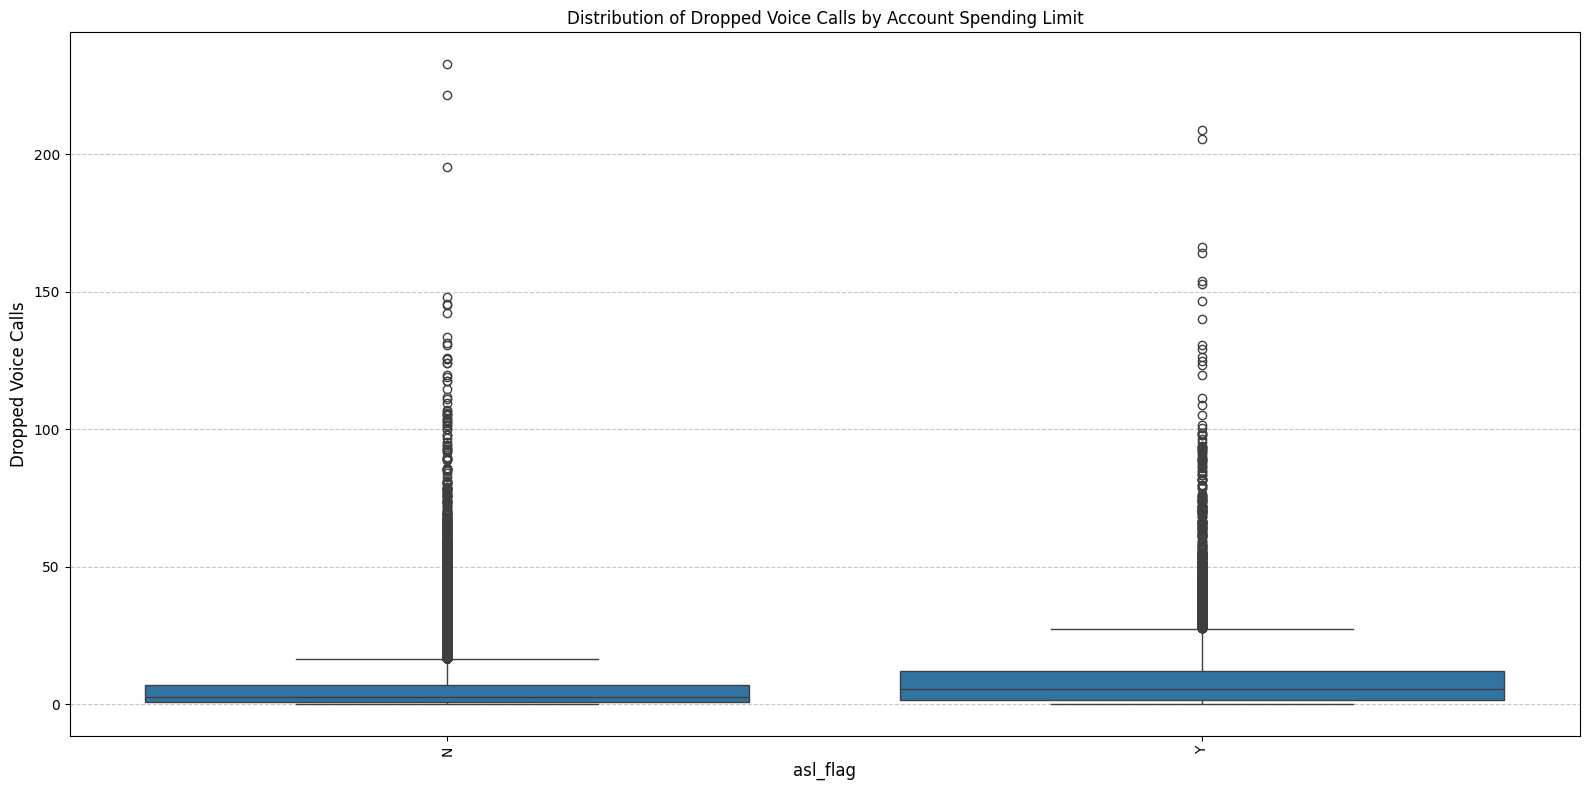

In [124]:
plt.figure(figsize=(16, 8)) # Increased figure size
sns.boxplot(x='asl_flag',y='drop_vce_Mean',data=df)
plt.title('Distribution of Dropped Voice Calls by Account Spending Limit')
plt.xlabel('asl_flag', fontsize=12)
plt.ylabel('Dropped Voice Calls', fontsize=12) # Increased y-axis label font size
plt.xticks(rotation=90, fontsize=10) # Rotate x-axis labels for better readability and increased font size
plt.yticks(fontsize=10) # Increased y-axis tick label font size
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added horizontal grid lines
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [135]:
import numpy as np
df['High_drop'] = np.where(df['drop_vce_Mean'] > 6, 1, 0)

<Axes: ylabel='Feature'>

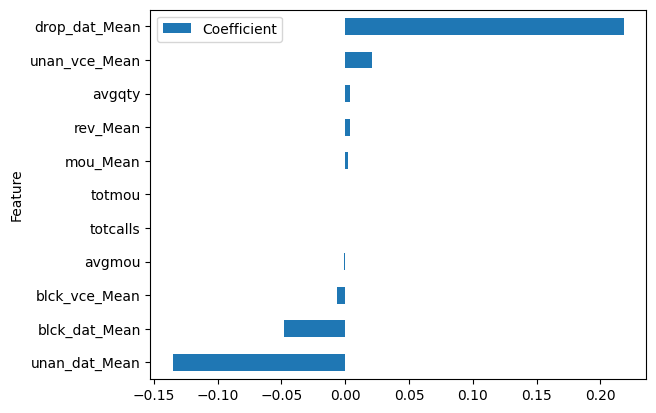

In [136]:


importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

importance.sort_values('Coefficient').plot(
    x='Feature',
    y='Coefficient',
    kind='barh'
)

In [133]:
from re import X
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
threshold=df['drop_vce_Mean'].mean()
df['High_drop'] = np.where(df['drop_vce_Mean'] > threshold, 1, 0).astype(int)

features = ['rev_Mean', 'mou_Mean', 'avgmou', 'avgqty', 'totmou', 'totcalls',  'blck_vce_Mean', 'unan_vce_Mean', 'blck_dat_Mean', 'drop_dat_Mean', 'unan_dat_Mean']

X = df[features]
y = df['High_drop']
print(df['High_drop'].value_counts())
print(df['High_drop'].value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)


print(classification_report(y_test, y_pred))

print("Accuracy:", accuracy)
print("ROC AUC:", roc_auc)

High_drop
0    67827
1    32173
Name: count, dtype: int64
High_drop
0    0.67827
1    0.32173
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       0.81      0.91      0.86     13574
           1       0.75      0.54      0.62      6426

    accuracy                           0.79     20000
   macro avg       0.78      0.73      0.74     20000
weighted avg       0.79      0.79      0.78     20000

Accuracy: 0.7927
ROC AUC: 0.8649566271837222


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


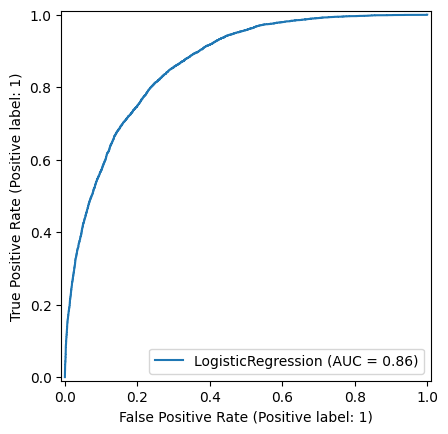

In [134]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)


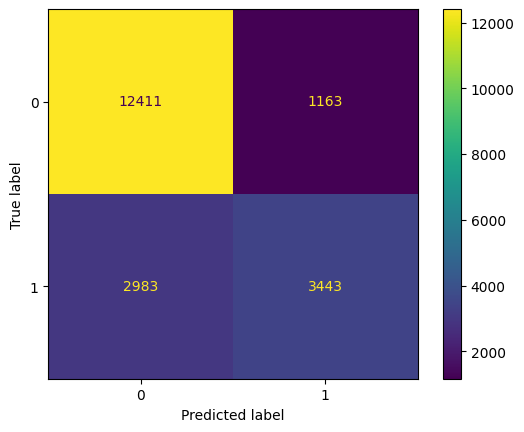

In [138]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

